# Result 2: A comparison with other individual parcellation approaches

In result 2, we demenstrate a comparison between group/individual parcellations generated from existing algorithm and our proposed HBP framework. There are two major individual parcellation methods: 1) MSHBM using resting-state fMRI from Yeo lab (17 networks), 2) InfoMap using rs-fMRI from Gordon group (17 network and varying number).

In [1]:
import time
import numpy as np
# import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
# import HierarchBayesParcel.arrangements as ar
# import HierarchBayesParcel.emissions as em
# import HierarchBayesParcel.full_model as fm
# import FusionModel.util as futil
# import FusionModel.evaluate as ev
from pathlib import Path

ERIS_DIR = '/home/dzhi/eris_mount'
if not Path(ERIS_DIR).exists():
    ERIS_DIR = '/data/tge'
if not Path(ERIS_DIR).exists():
    raise (NameError('Could not find hcp_dir'))

RES_DIR = ERIS_DIR + '/dzhi/Indiv_par/Evaluations'

In [2]:
import os, sys 
sys.path.append(os.path.abspath('..'))

# from global_config import MODEL_DIR, BASE_DIR, ATLAS_DIR, DEVICE
# from scripts.group_parcellation import build_ukb_datasets, convert_hard_to_prob, get_indiv_parcellation_from_model
# from scripts.indiv_eval import *

## Group level: trained on same HCP 40 subjects resting-state data

### Left: MSHBM, Right: HBP

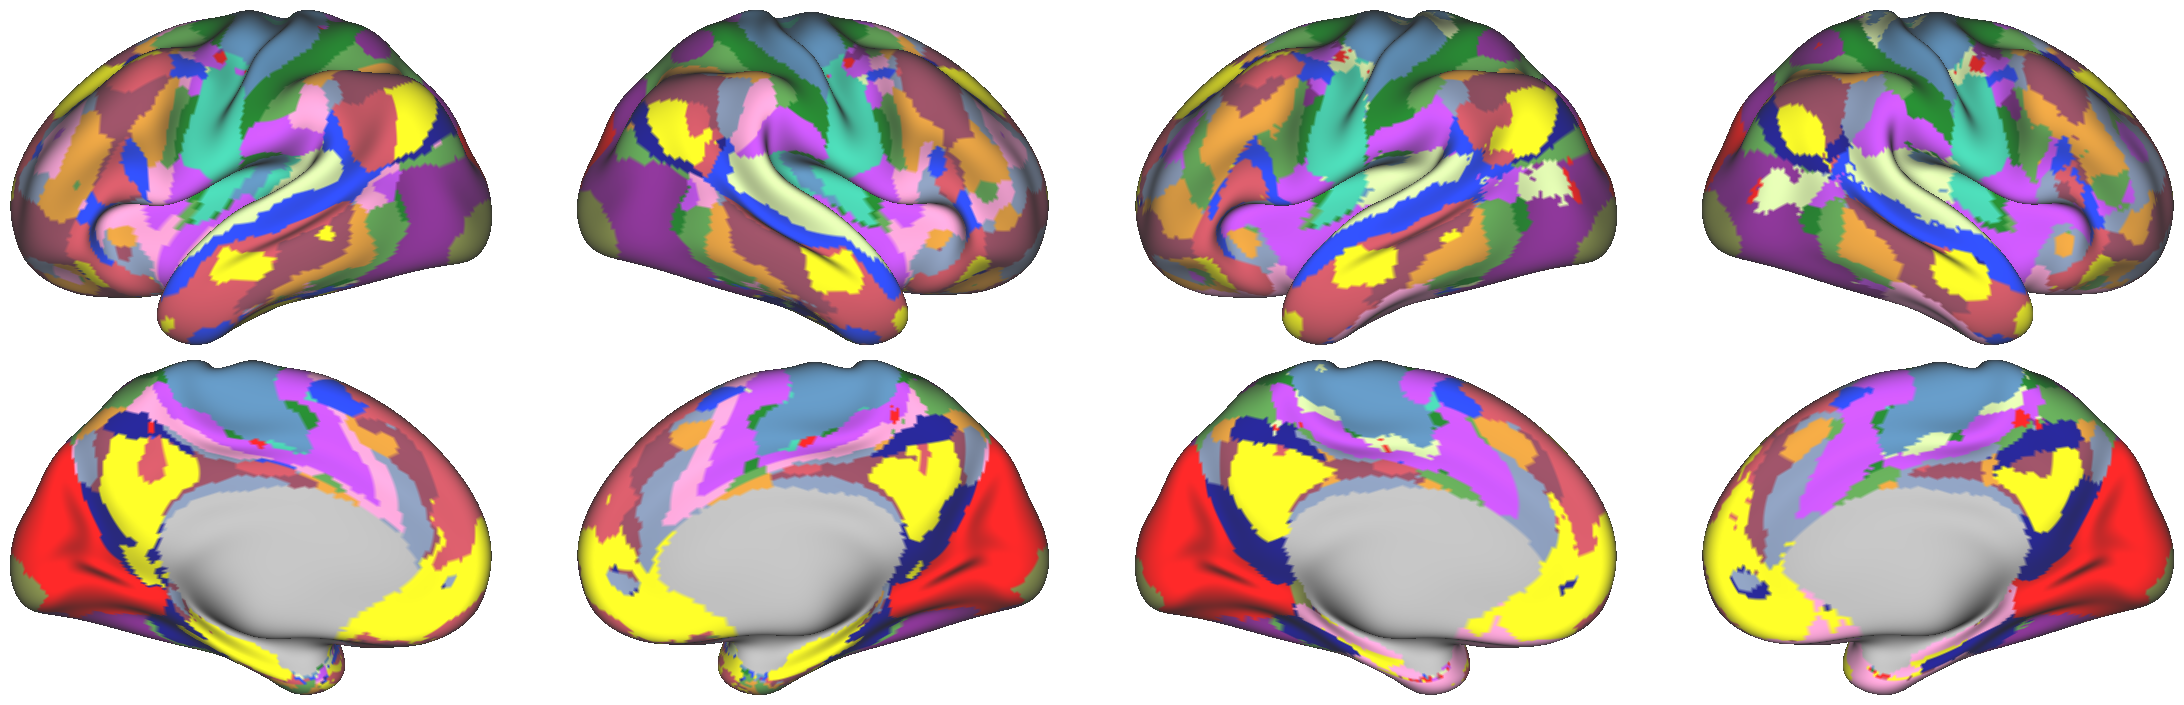

In [5]:
from IPython.display import Image, display, HTML
display(Image(filename='/data/tge/dzhi/Indiv_par/Results/section_2/HBP_vs_MSHBM_rest_group.png'))

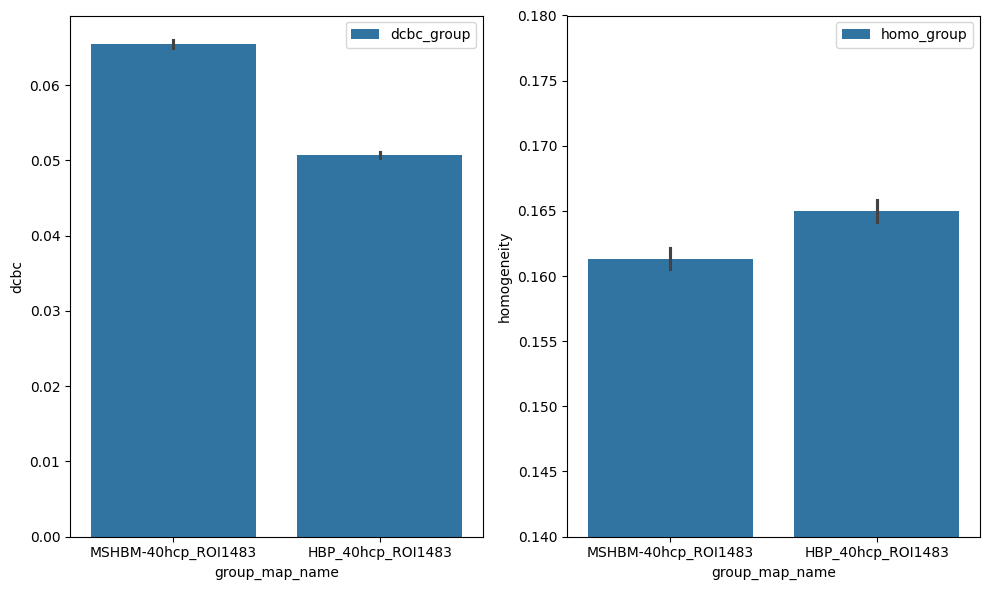

(923,)


TtestResult(statistic=-89.4688273211044, pvalue=0.0, df=922)

In [46]:
res_dir = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.read_csv(res_dir + f'/eval_MSHBM_vs_HBP_on-HCPtest_sm-4fwhm.tsv', sep='\t')

# baseline = results.loc[results.group_map_name == 'Kong2019']
# to_compare = results.loc[results.group_map_name == 'MSHBM-40hcp_wb']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se",
            label='dcbc_group')
# plt.axhline(y=baseline.dcbc_group.mean(), color='k', linestyle=':')
# plt.axhline(y=to_compare.dcbc_group.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_group', errorbar="se",
            label='homo_group')
# plt.axhline(y=baseline.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=to_compare.homo_group.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.ylim(0.14, 0.18)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/existing_vs_ukb.pdf', format='pdf')
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'MSHBM-40hcp_ROI1483']
b = results.loc[results.group_map_name == 'HBP_40hcp_ROI1483']

mshbm = a.groupby('subj_num')['homo_group'].mean()
hbp = b.groupby('subj_num')['homo_group'].mean()
print(mshbm.shape)
stats.ttest_rel(mshbm, hbp)

# Individual level

Both algorithm utilize a validation set of 40 HCP subjects to fine-tuning the hyper-parameters. Here, we match the same 40 subjects to fine tune the two parameters of HBP, group strengthness and spatial smoothness. The former is to control how similar the resulting individual parcellations to the group map, the latter used to give spatial smoothness. 

# Grid search of parameters on 40 validation subjects

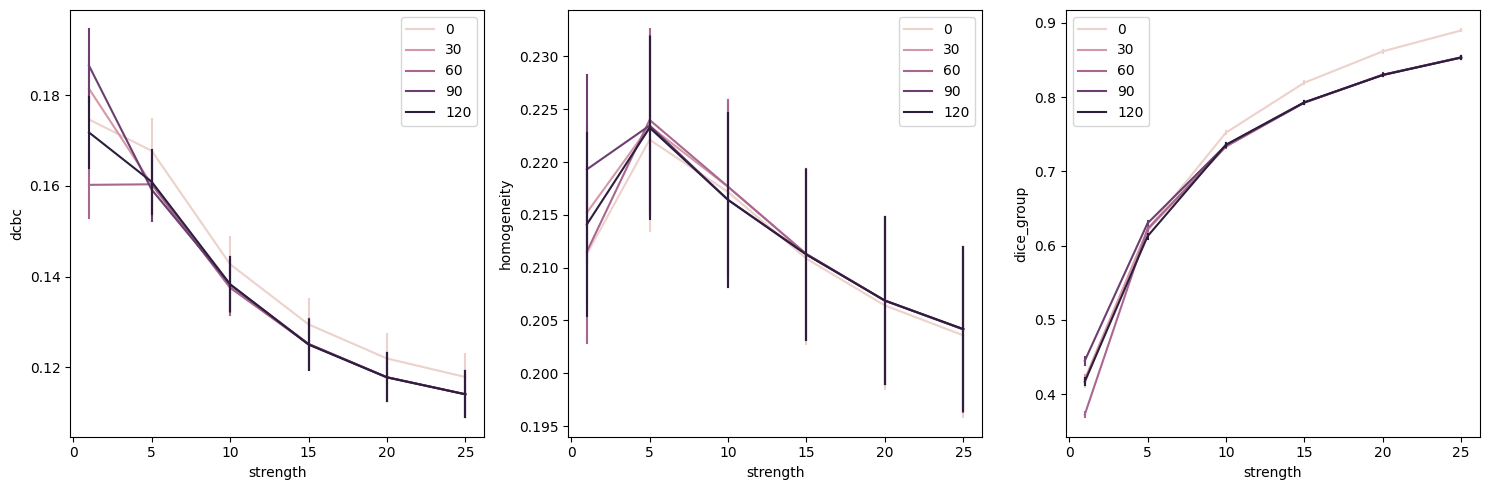

In [42]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_task_vs_rest_indiv_on-Md_prior-taskfusion.tsv', sep='\t')

kong_res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCP40_on_40validation_Tseries_desc-sm4fwhm.tsv',
                      sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
# sb.lineplot(data=results, x="strength", y='dcbc_group', errorbar="se",
#             err_style="bars", markers=True, markersize=10)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
# plt.axhline(y=kong_res.dcbc_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.dcbc_indiv.mean(), color='r', linestyle=':')

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
# sb.lineplot(data=results, x="strength", y='homo_group', errorbar="se",
#             err_style="bars", markers=True, markersize=10)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
# plt.axhline(y=kong_res.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.homo_indiv.mean(), color='r', linestyle=':')

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.savefig('/data/tge/dzhi/test.png', format='png')
plt.show()

# Individual parcellation on test set (first 50 subjects)

## 1. Homogeneity - HCP rest

/tmp/ipykernel_38232/2700625989.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_38232/2700625989.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


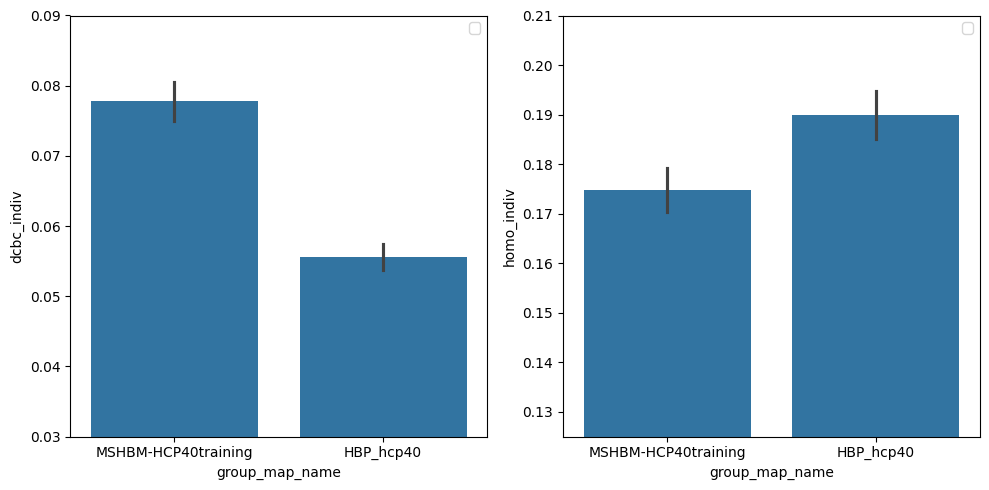

(150,)


TtestResult(statistic=np.float64(-20.16225691751626), pvalue=np.float64(2.0129216599828647e-44), df=np.int64(149))

In [8]:
eval_dir = '/data/tge/dzhi/Indiv_par/Evaluations'

results1 = pd.read_csv(eval_dir + f'/eval_HCP923test_groupstrength-60_spatialW-90.tsv', sep='\t')
results1 = results1.replace("/Models_03/asym_Hc_space-fs32k_K-17_HCP40subjects_Ico642Run_desc-sm4fwhm_binarized", "HBP_hcp40")

# results1 = pd.read_csv(eval_dir + f'/eval_MSHBM_vs_HBP_indiv_on-HCPtest_sm-4fwhm_split-1.tsv', sep='\t')
results2 = pd.read_csv(eval_dir + f'/eval_MSHBM-HCP_test-indiv_on_50test_Tseries_desc-sm4fwhm.tsv',
                      sep='\t')
results = pd.concat([results2, results1], ignore_index=True)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_indiv', errorbar="se")
plt.ylabel('dcbc_indiv')
plt.ylim(0.03,0.09)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='homo_indiv', errorbar="se")
# plt.axhline(y=kong_res.homo_group.mean(), color='k', linestyle=':')
# plt.axhline(y=kong_res.homo_indiv.mean(), color='r', linestyle=':')
plt.ylabel('homo_indiv')
plt.ylim(0.125,0.21)
plt.legend()

plt.tight_layout()
# plt.savefig('/data/tge/dzhi/indiv_homo.pdf', format='pdf')
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'MSHBM-HCP40training']
b = results.loc[results.group_map_name == 'HBP_hcp40']

print(a.homo_indiv.shape)
stats.ttest_rel(a.homo_indiv, b.homo_indiv)

## 2. Inhomogeneity - HCP task

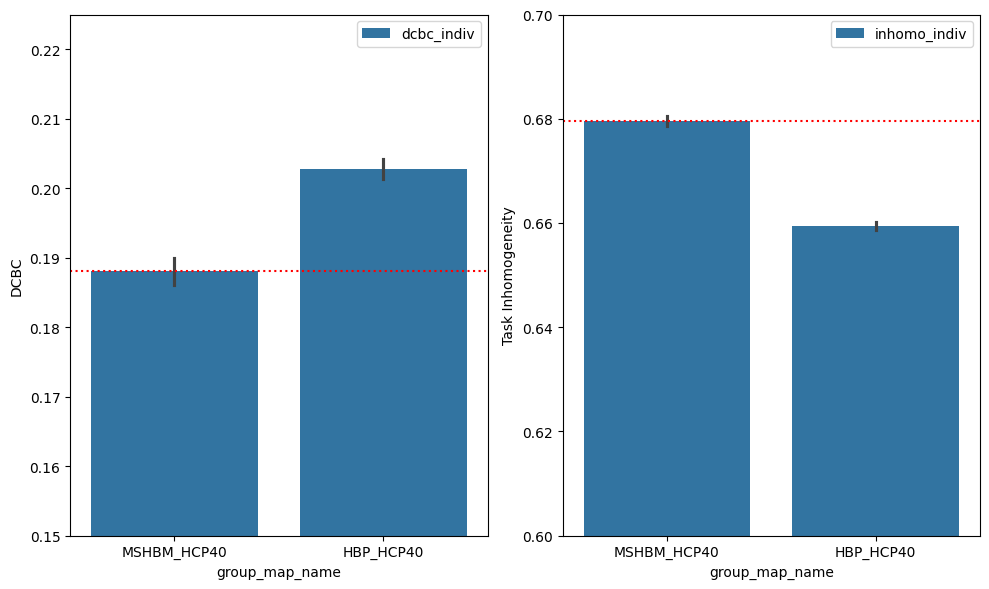

(50,)


TtestResult(statistic=18.981848489198455, pvalue=3.1309055772251493e-24, df=49)

In [6]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_indiv_teston-Task.tsv', sep='\t')

to_compare = results.loc[results.group_map_name == 'MSHBM_HCP40']

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_indiv', errorbar="se", label='dcbc_indiv')
plt.axhline(y=to_compare.dcbc_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.15, 0.225)
plt.ylabel('DCBC')
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='inhomo_indiv', errorbar="se", label='inhomo_indiv')
plt.axhline(y=to_compare.inhomo_indiv.mean(), color='r', linestyle=':')

plt.ylabel('Task Inhomogeneity')
plt.ylim(0.6, 0.7)
plt.legend()
plt.tight_layout()
plt.savefig('/data/tge/dzhi/indiv_task_inhomo.pdf', format='pdf')
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'MSHBM_HCP40']
b = results.loc[results.group_map_name == 'HBP_HCP40']

print(a.inhomo_indiv.shape)
stats.ttest_rel(a.inhomo_indiv, b.inhomo_indiv)

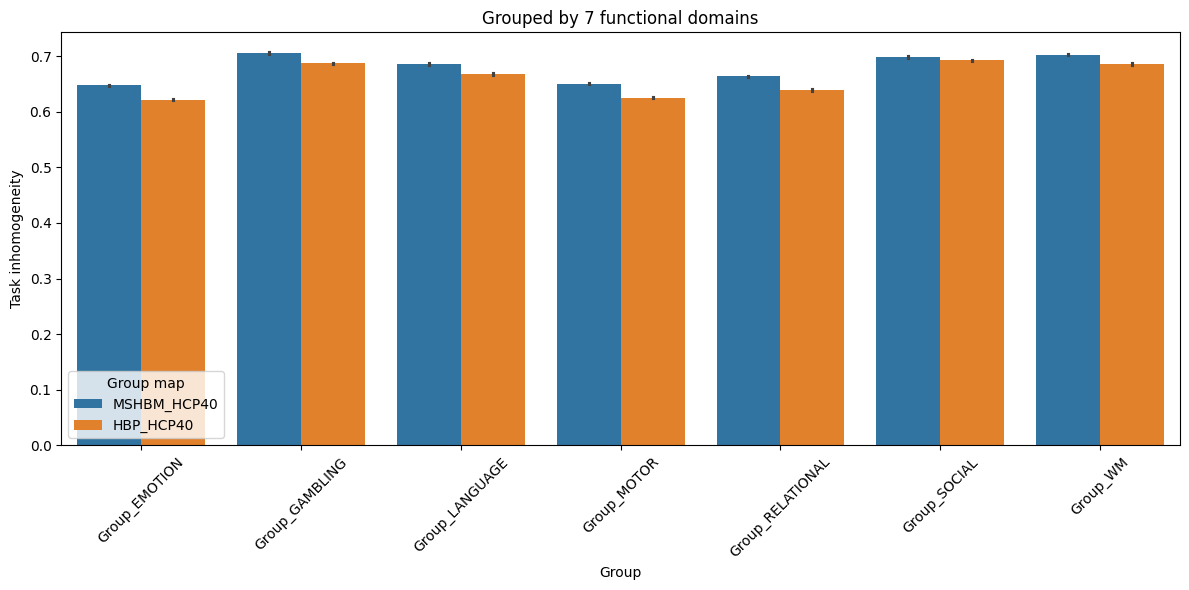

In [33]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM_vs_HBP_indiv_teston-Task_separate_test.tsv', sep='\t')

contrast_file = '/data/tge/Tian/HCP_img' + '/rfMRI/fix_32k/group/' + \
                    'HCP_S1200_997_tfMRI_ALLTASKS_level2_cohensd_hp200_s2_MSMAll.dscalar.nii'
task_name = np.array(nb.load(contrast_file).header.get_axis(0).name, dtype=object)

group_vector = [s.split('_')[1] for s in task_name]

cond_names = [f'inhomo_indiv_{i}' for i in task_name]
grouped_data = pd.DataFrame({'group_map_name': results['group_map_name']})

# Group the conditions based on the group vector
for group in np.unique(group_vector):
    group_conditions = [cond_names[i] for i in range(len(group_vector)) if group_vector[i] == group]
    grouped_data[f'Group_{group}'] = results[group_conditions].mean(axis=1)

df_grouped_melted = pd.melt(grouped_data, id_vars='group_map_name',
                            value_vars=[f'Group_{s}' for s in np.unique(group_vector)],
                            var_name='Group', value_name='Mean')

# Plot the bar plot
plt.figure(figsize=(12, 6))
sb.barplot(x='Group', y='Mean', hue='group_map_name', data=df_grouped_melted, errorbar='se', dodge=True)

# Customize the plot
plt.title('Grouped by 7 functional domains')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Group map')

plt.ylabel('Task inhomogeneity')

# Show the plot
plt.tight_layout()
plt.show()

# Reproducibility test - Individual parcellations (HCP test)

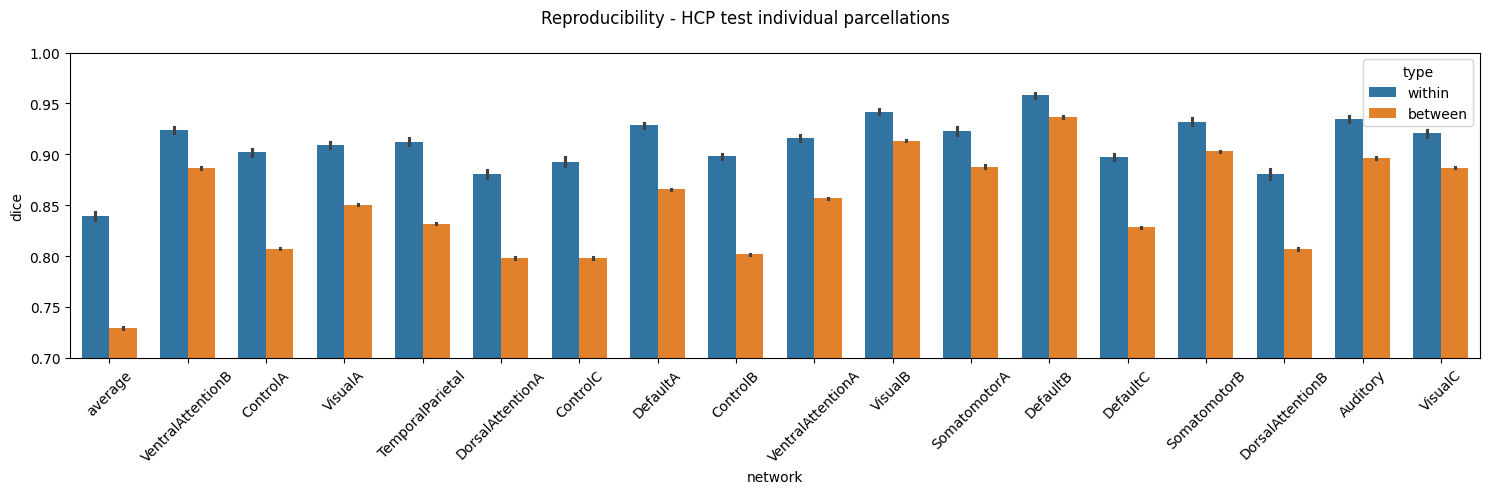

In [5]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.read_csv(RES_DIR + f'/reproducibility_MSHBM_vs_HBP_indiv_HCPtest.tsv', sep='\t')

# Plot results
plt.figure(figsize=(15, 5))
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='network', y='dice', hue='type', 
           errorbar='se', width=0.7)

plt.xticks(rotation=45)
plt.ylim(0.7, 1)
plt.suptitle('Reproducibility - HCP test individual parcellations')
plt.tight_layout()
plt.show()

## Group parcellation by different amount of subjects

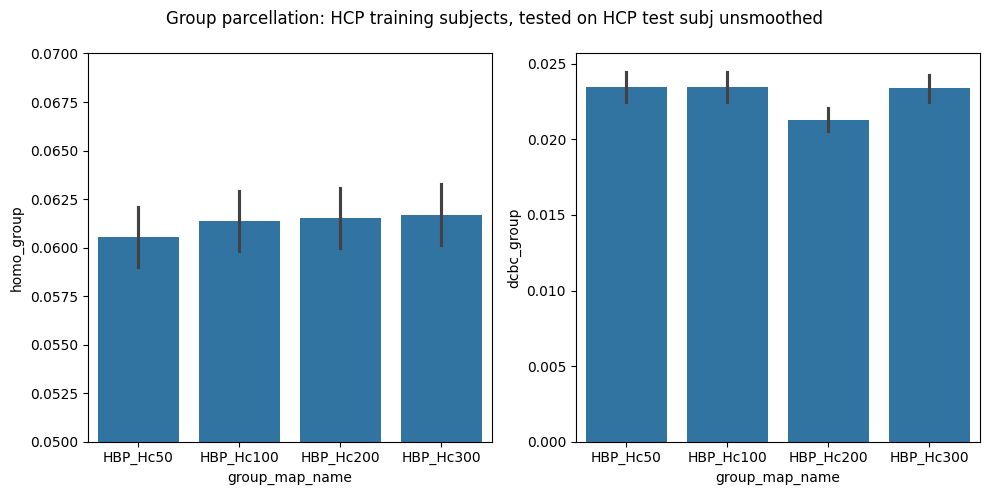

In [3]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HBP-Hc50to300_on-HCPtest.tsv', sep='\t')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.05, 0.07)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

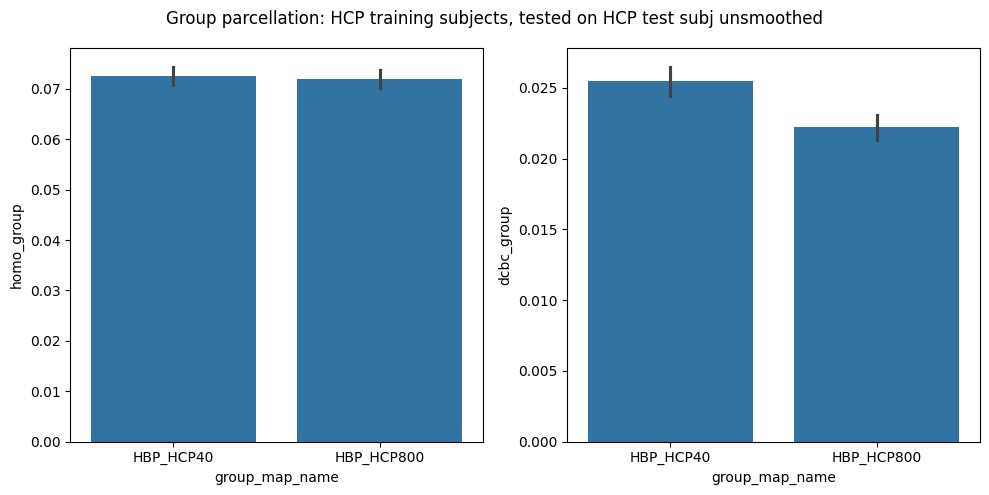

In [9]:
result = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800_K-17_on-HCPtest_split-{i}.tsv', sep='\t')
    result = pd.concat([result, res], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()


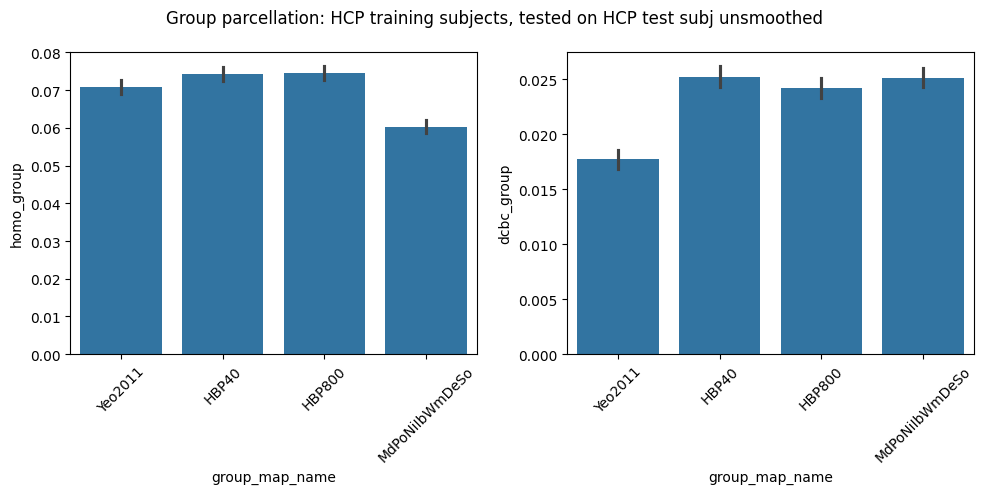

In [3]:
res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-maps_on-HCPtest_split-1.tsv', sep='\t')
    
   
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=res, x='group_map_name', y='homo_group', errorbar='se')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=res, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Test group parcellations on HCP test data (unsmoothed)

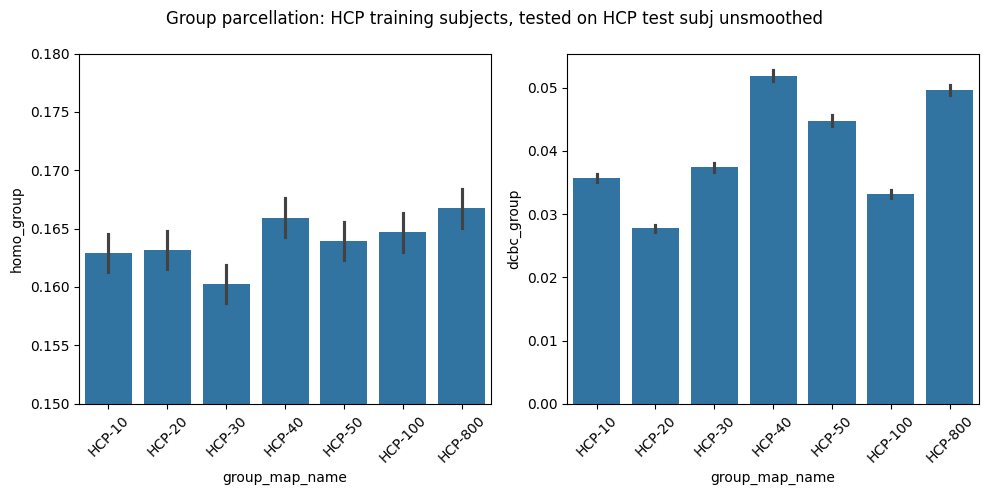

In [11]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HCP10-800_on-HCPtest-sm4fwhm_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.15, 0.18)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HCP training subjects, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Group: HBP vs Existing on HCP 203 test subjects (unsmoothed)

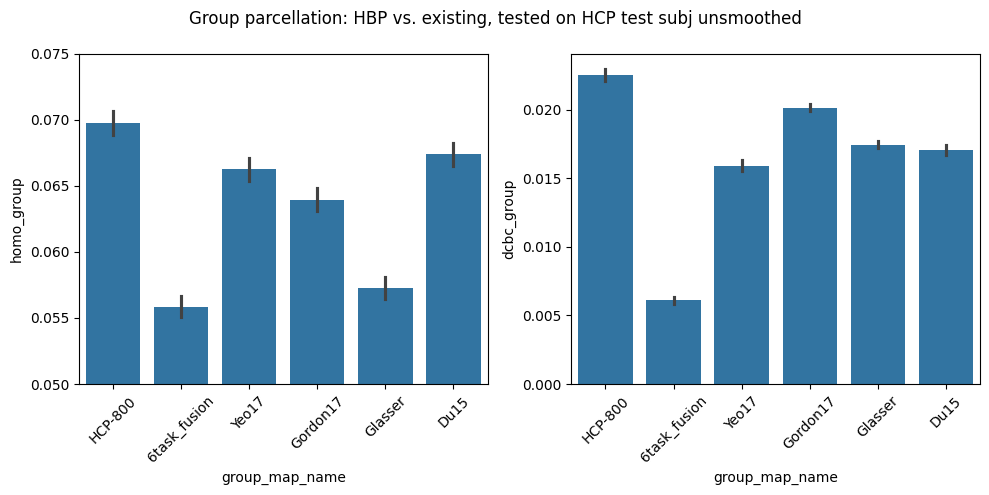

In [37]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-HCPtest_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se')
plt.ylim(0.05, 0.075)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on HCP test subj unsmoothed')
plt.tight_layout()
plt.show()

## Group: Evaluate on MDTB 24 test subjects (unsmoothed, by tasks)

['GoNoGo' 'ToM' 'actionObservation' 'affective' 'arithmetic'
 'checkerBoard' 'emotional' 'intervalTiming' 'motorImagery'
 'motorSequence' 'nBack' 'nBackPic' 'spatialNavigation' 'stroop'
 'verbGeneration' 'visualSearch' 'rest' 'CPRO' 'prediction' 'spatialMap'
 'natureMovie' 'romanceMovie' 'landscapeMovie' 'mentalRotation'
 'emotionProcess' 'respAlt']


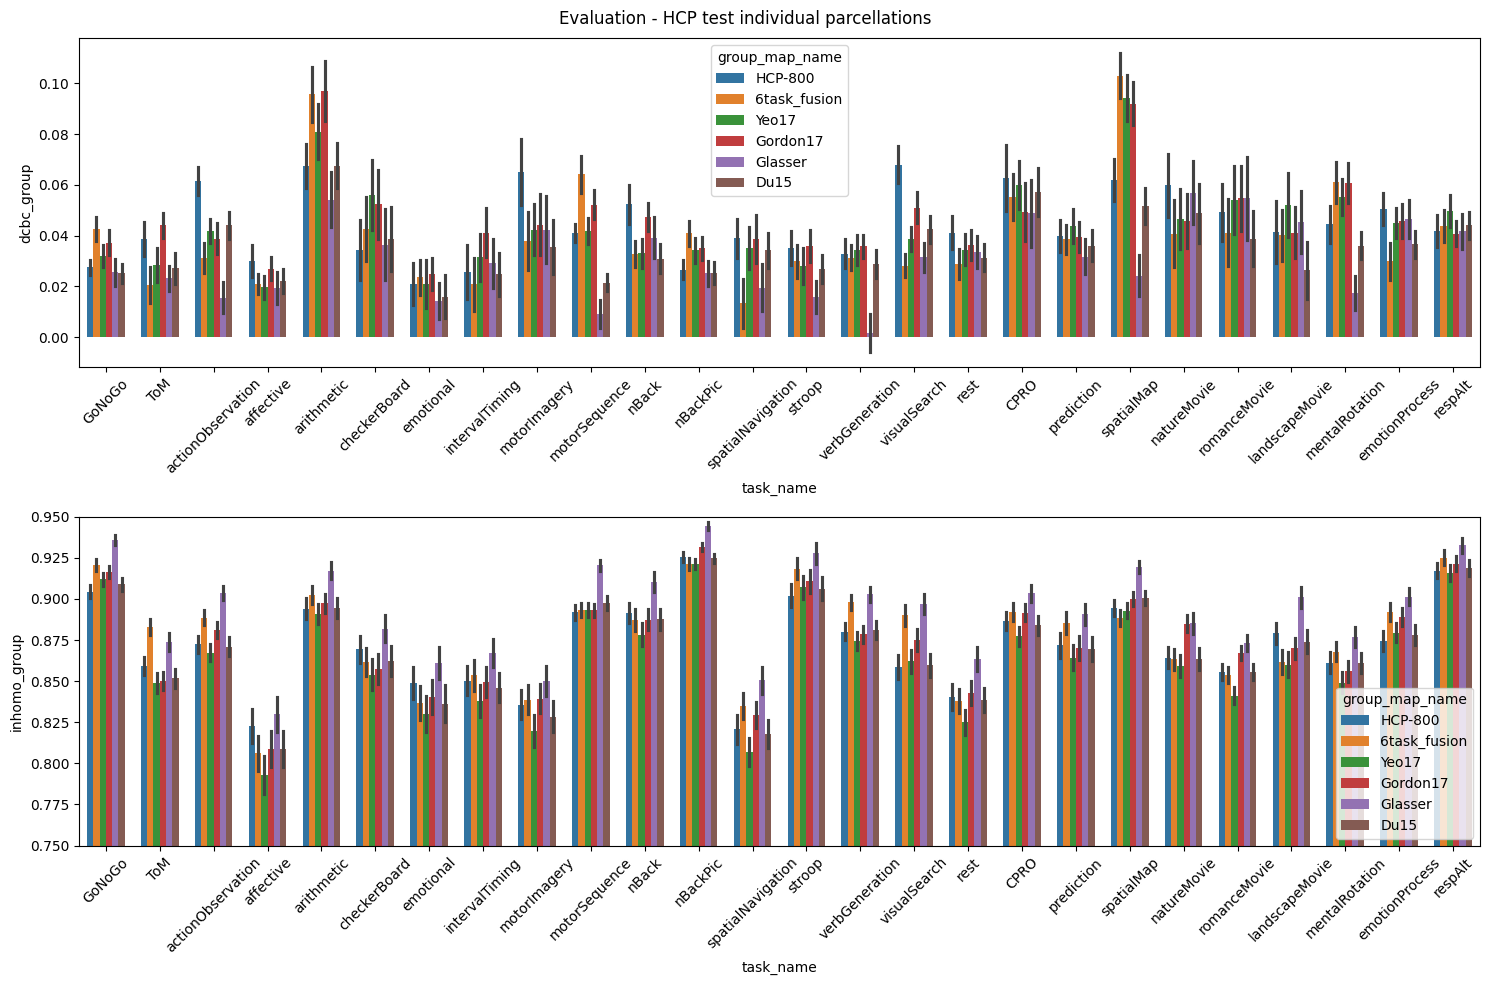

In [7]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results = pd.read_csv(RES_DIR + f'/eval_group-HBP_vs_existing_on-MDTB-by-functionaldomains.tsv', sep='\t')
results = results.loc[results['group_map_name'] != '7task_fusion']

print(results.task_name.unique())
# results = results.replace(results.task_name.unique(), ['Executive', 'Social', 'Motor', 'Emotion', 'Numerical', 'Perception',
#                                           'Emotion', 'Temporal', 'Motor', 'Motor', 'Executive', 'Executive', 'Spatial',
#                                           'Executive', 'Language', 'Perception', 'Rest', 'Executive', 'Executive',
#                                           'Spatial', 'Social', 'Social', 'Perception', 'Spatial', 'Emotion', 'Motor'])

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_group', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_group', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.ylim(0.75, 0.95)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()
plt.show()

## Group: HBP vs Existing on HCP test 203 subjects task fMRI (unsmoothed)

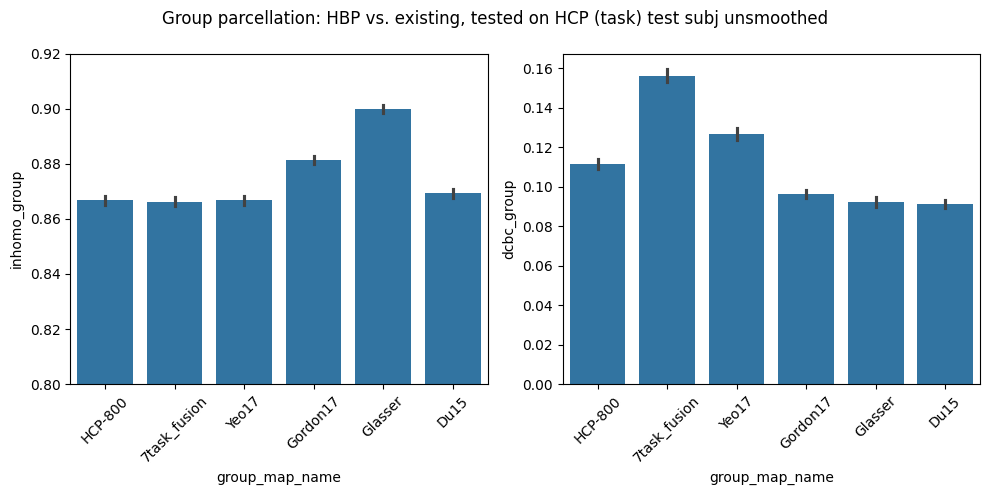

In [9]:
results = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-HCPtest-task_split-{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)
    
results = results.loc[results['group_map_name'] != '6task_fusion']
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', errorbar='se')
plt.ylim(0.8, 0.92)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on HCP (task) test subj unsmoothed')
plt.tight_layout()
plt.show()

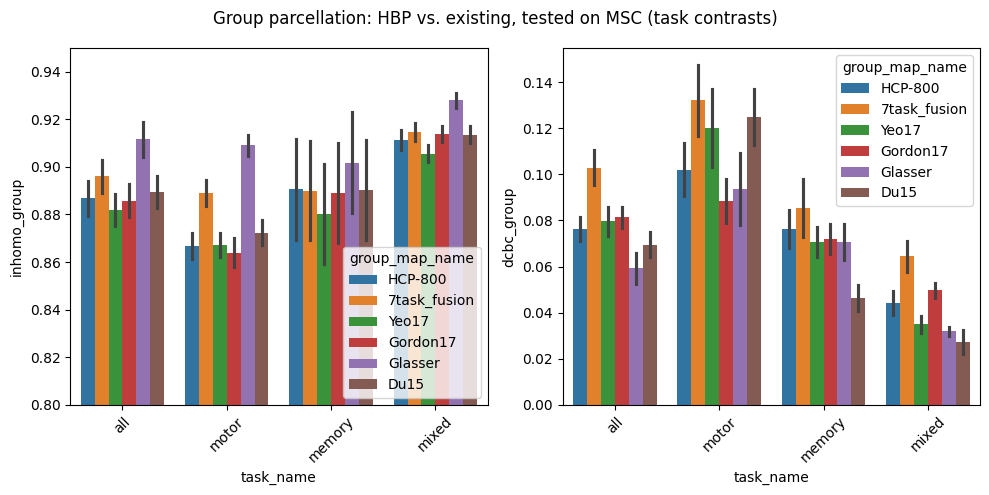

In [7]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-MSC-task-contrasts.tsv', sep='\t')
    
results = results.loc[results['group_map_name'] != '6task_fusion']
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='task_name', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.ylim(0.8, 0.95)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MSC (task contrasts)')
plt.tight_layout()
plt.show()

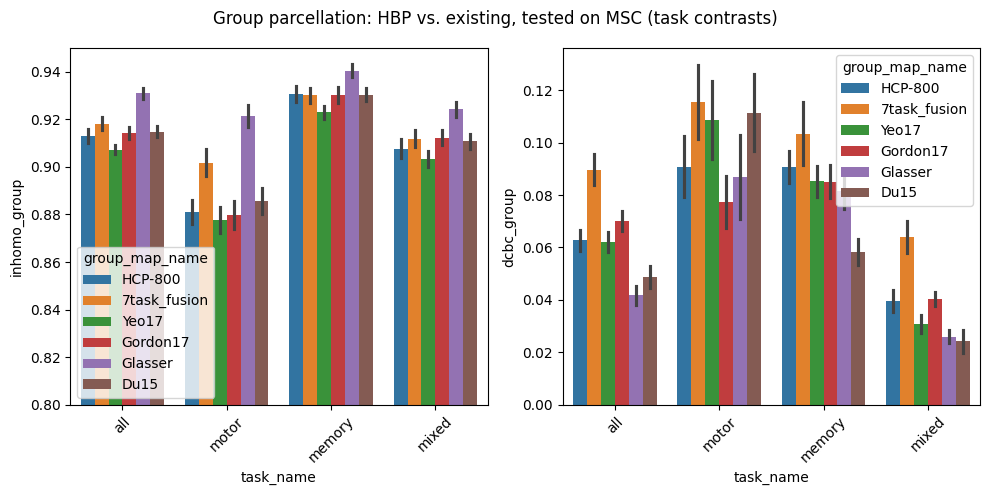

In [4]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-MSC-task-contrasts_2.tsv', sep='\t')
    
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='task_name', y='inhomo_group', hue='group_map_name', errorbar='se')
plt.ylim(0.8, 0.95)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='dcbc_group', hue='group_map_name', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MSC (task contrasts)')
plt.tight_layout()
plt.show()

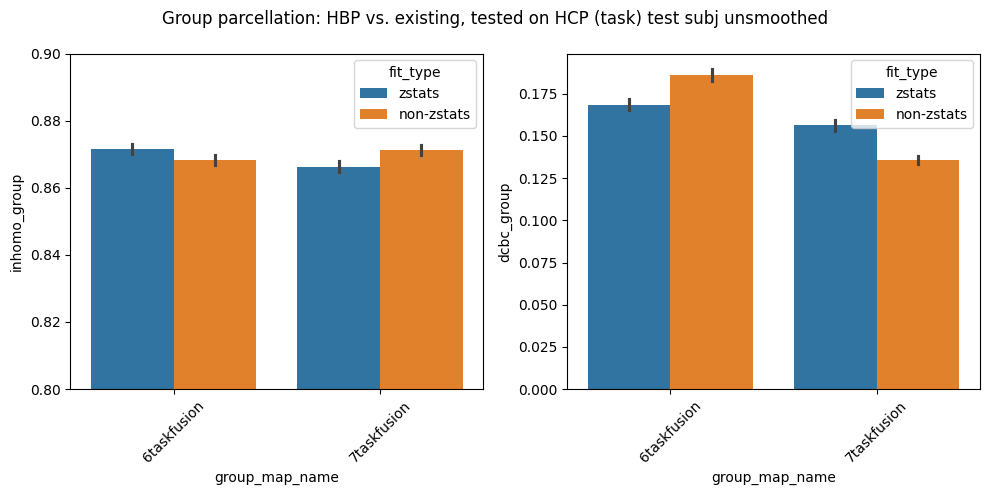

In [36]:
results_new = pd.DataFrame()
for i in [1,2,3,4]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_vs_existing_on-HCPtest-task_split-{i}.tsv', sep='\t')
    results_new = pd.concat([results_new, res], ignore_index=True)

results_new = results_new.replace(['6task_fusion', '7task_fusion'], ['6taskfusion', '7taskfusion'])
results_new['fit_type'] = 'zstats'
results_new = results_new.loc[results_new['group_map_name'].isin(['6taskfusion', '7taskfusion'])]

results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-taskfusion-old_on-HCPtest-task.tsv', sep='\t')
results['fit_type'] = 'non-zstats'

results = pd.concat([results_new, results], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', hue='fit_type', errorbar='se')
plt.ylim(0.8,0.9)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', hue='fit_type', errorbar='se')

plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on HCP (task) test subj unsmoothed')
plt.tight_layout()
plt.show()

## Comparing task fusion group atlas (K=15) by different smoothing (test on HCP 203)

(764, 17) (191, 17)


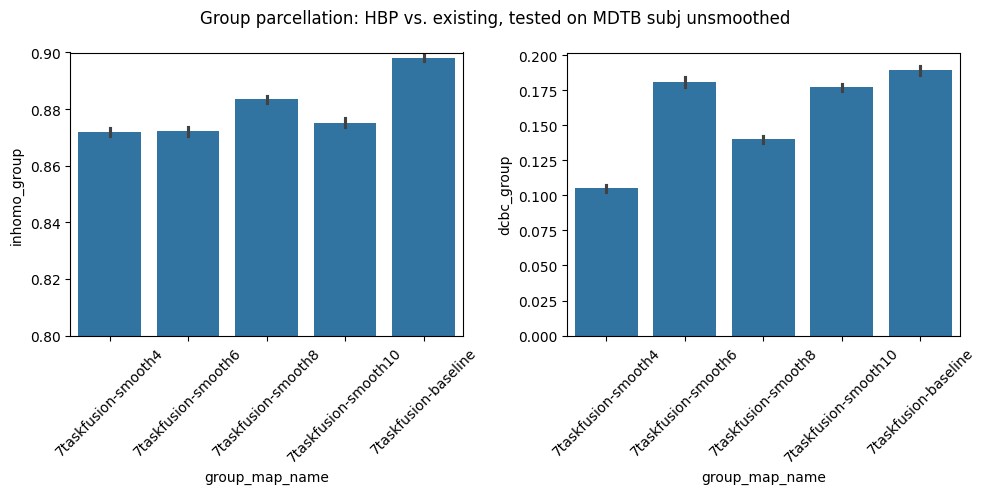

In [6]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_7taskfusion_K-15_sm4-10_on-HCP203test-task.tsv', sep='\t')

print(results1.shape, results2.shape)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='inhomo_group', errorbar='se')
plt.ylim(0.8,0.9)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se')
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MDTB subj unsmoothed')
plt.tight_layout()
plt.show()

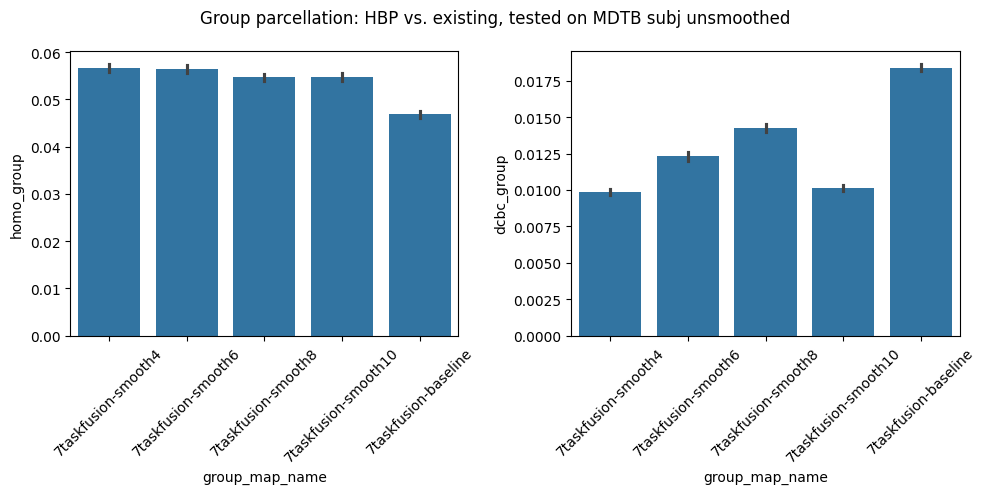

In [11]:
results = pd.DataFrame()
for i in [0,1,2,3]:
    res = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group-HBP_7taskfusion_K-15_sm4-10_on-HCP203test-rest-run{i}.tsv', sep='\t')
    results = pd.concat([results, res], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x='group_map_name', y='homo_group', errorbar='se', 
           order=['7taskfusion-smooth4','7taskfusion-smooth6','7taskfusion-smooth8','7taskfusion-smooth10','7taskfusion-baseline'])

plt.xticks(rotation=45)

plt.subplot(1,2,2)
sb.barplot(data=results, x='group_map_name', y='dcbc_group', errorbar='se',
          order=['7taskfusion-smooth4','7taskfusion-smooth6','7taskfusion-smooth8','7taskfusion-smooth10','7taskfusion-baseline'])
plt.xticks(rotation=45)

plt.suptitle('Group parcellation: HBP vs. existing, tested on MDTB subj unsmoothed')
plt.tight_layout()
plt.show()

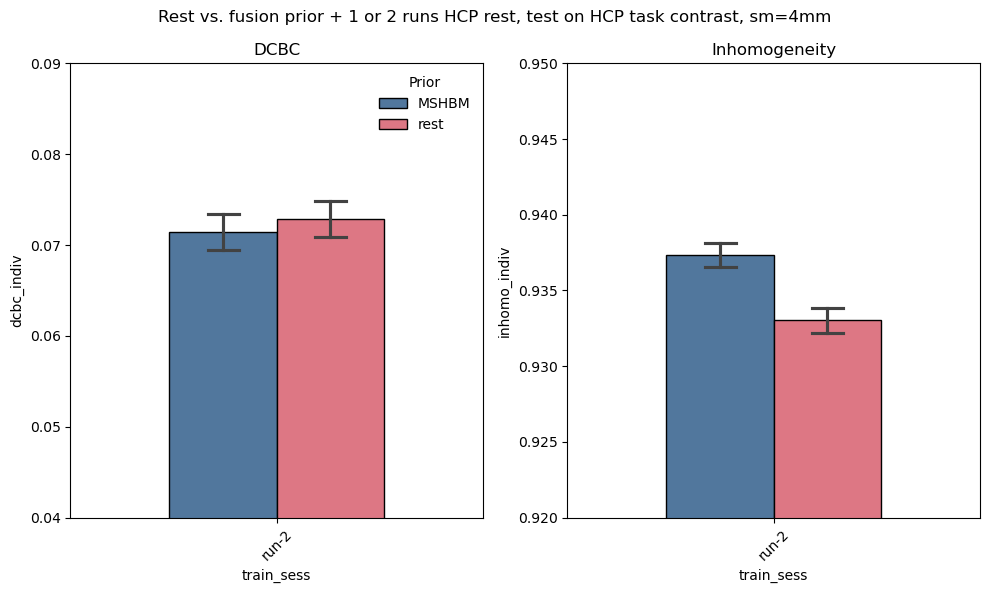

0.07142066722055408 0.9373408824759812
TtestResult(statistic=25.852126010202312, pvalue=1.5643695480108543e-65, df=199)
TtestResult(statistic=-2.8820550425626568, pvalue=0.00438468102455471, df=199)


In [12]:
HCP200_DIR = ERIS_DIR + "/dzhi/Indiv_par/Results/section_4/HCP"

df_rest = pd.read_csv(HCP200_DIR + f'/eval_indiv-mRBM_HBP-HCP200_1-2run_K-17_test_on_HCPtask-contrast_sm4.tsv', sep='\t')
df_rest['type'] = 'rest'

df_fusion = pd.read_csv(HCP200_DIR + f'/eval_indiv-mRBM_MdNiIbHc-HCP200_1-2run_K-17_test_on_HCPtask-contrast_sm4.tsv', sep='\t')
df_fusion['type'] = 'fusion'

kong_indiv = pd.read_csv(ERIS_DIR + f'/dzhi/Indiv_par/Results/section_2/eval_indiv-mRBM_MSHBM-HCP200_1-4run_K-17_test_on_HCPtask-allcontrasts_sm4_new.tsv', sep='\t')
kong_indiv['type'] = 'MSHBM'

kong_indiv = kong_indiv.loc[(kong_indiv['train_sess'] == 'run-2') & (kong_indiv['task_name'] == 'all')]
results = pd.concat([df_rest, df_fusion, kong_indiv], ignore_index=True)
results = results.loc[(results["task_name"] == "all") & (results['train_sess'] == 'run-2')]

# ------------------ styling ------------------
hue_order = ["MSHBM", "rest"]
palette = {
    "MSHBM": "#4477AA",
    "rest": "#EE6677",
    "fusion": "#009E73"
}

BAR_WIDTH = 0.52      # <--- controls gap size
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15

# ------------------ figure ------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True)

# ================== DCBC ==================
sb.barplot(
    data=results,
    x="train_sess",
    y="dcbc_indiv",
    hue="type",
    hue_order=hue_order,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=palette,
    dodge=True,
    ax=axes[0]
)

# stroke all bars
for bar in axes[0].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[0].set_ylim(0.04, 0.09)
axes[0].set_title("DCBC")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Prior", frameon=False)

# ================== Inhomogeneity ==================
sb.barplot(
    data=results,
    x="train_sess",
    y="inhomo_indiv",
    hue="type",
    hue_order=hue_order,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=palette,
    dodge=True,
    ax=axes[1]
)

# stroke all bars
for bar in axes[1].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[1].set_ylim(0.92, 0.95)
axes[1].set_title("Inhomogeneity")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend_.remove()

# ------------------ final layout ------------------
fig.suptitle(
    "Rest vs. fusion prior + 1 or 2 runs HCP rest, test on HCP task contrast, sm=4mm"
)
fig.tight_layout()
fig.savefig(ERIS_DIR + '/dzhi/Indiv_par/Results/section_2/MSHBM_vs_HBP_contrast.pdf', format='pdf')
plt.show()


print(kong_indiv.dcbc_indiv.mean(), kong_indiv.inhomo_indiv.mean())
from scipy import stats
kong = kong_indiv.loc[(kong_indiv.task_name == 'all')].groupby(["subj_num"])
rest_2run = results.loc[(results.type == 'rest') & (results.task_name == 'all') & (results.train_sess == 'run-2')].groupby(["subj_num"])
fusion_2run = results.loc[(results.type == 'fusion') & (results.task_name == 'all') & (results.train_sess == 'run-2')].groupby(["subj_num"])

print(stats.ttest_rel(kong.inhomo_indiv.mean(), rest_2run.inhomo_indiv.mean()))
print(stats.ttest_rel(kong.dcbc_indiv.mean(), rest_2run.dcbc_indiv.mean()))

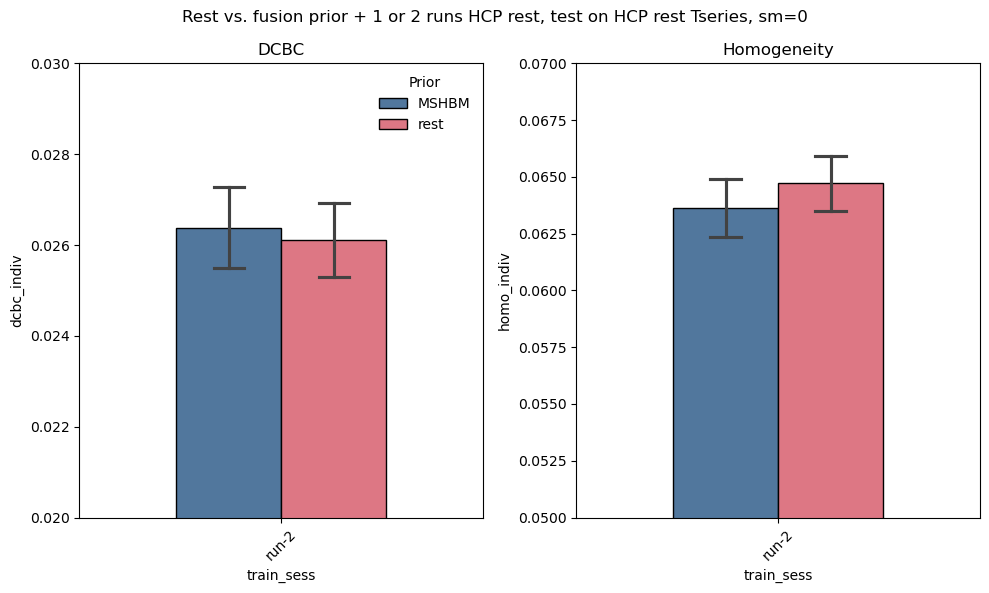

0.026385254371749985 0.06362557627249996
TtestResult(statistic=-8.27332318532372, pvalue=1.8510630981796922e-14, df=199)
TtestResult(statistic=1.3233789467822354, pvalue=0.18722780568400607, df=199)


In [15]:
HCP200_DIR = ERIS_DIR + "/dzhi/Indiv_par/Results/section_4/HCP"

df_rest = pd.read_csv(HCP200_DIR + f'/eval_indiv-mRBM_HBP-HCP200_1-2run_K-17_test_on_HCPrest-Tseries.tsv', sep='\t')
df_rest['type'] = 'rest'

df_fusion = pd.read_csv(HCP200_DIR + f'/eval_indiv-mRBM_MdNiIbHc-HCP200_1-2run_K-17_test_on_HCPrest-Tseries.tsv', sep='\t')
df_fusion['type'] = 'fusion'

kong_indiv = pd.read_csv(ERIS_DIR + f'/dzhi/Indiv_par/Results/section_2/eval_indiv-mRBM_MSHBM-HCP200_1-2run_K-17_test_on_HCPrest-Tseries_sm0.tsv', sep='\t')
kong_indiv['type'] = 'MSHBM'

kong_indiv = kong_indiv.loc[(kong_indiv['train_sess'] == 'run-2') & (kong_indiv['task_name'] == 'all')]
results = pd.concat([df_rest, df_fusion, kong_indiv], ignore_index=True)
results = results.loc[(results["task_name"] == "all") & (results['train_sess'] == 'run-2')]

# ------------------ styling ------------------
hue_order = ["MSHBM", "rest"]
palette = {
    "MSHBM": "#4477AA",
    "rest": "#EE6677",
    "fusion": "#009E73"
}

BAR_WIDTH = 0.52      # <--- controls gap size
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15

# ------------------ figure ------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True)

# ================== DCBC ==================
sb.barplot(
    data=results,
    x="train_sess",
    y="dcbc_indiv",
    hue="type",
    hue_order=hue_order,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=palette,
    dodge=True,
    ax=axes[0]
)

# stroke all bars
for bar in axes[0].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[0].set_ylim(0.02, 0.03)
axes[0].set_title("DCBC")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Prior", frameon=False)

# ================== Inhomogeneity ==================
sb.barplot(
    data=results,
    x="train_sess",
    y="homo_indiv",
    hue="type",
    hue_order=hue_order,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=palette,
    dodge=True,
    ax=axes[1]
)

# stroke all bars
for bar in axes[1].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[1].set_ylim(0.05, 0.07)
axes[1].set_title("Homogeneity")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend_.remove()

# ------------------ final layout ------------------
fig.suptitle(
    "Rest vs. fusion prior + 1 or 2 runs HCP rest, test on HCP rest Tseries, sm=0"
)
fig.tight_layout()
fig.savefig(ERIS_DIR + '/dzhi/Indiv_par/Results/section_2/MSHBM_vs_HBP_Tseries.pdf', format='pdf')
plt.show()


print(kong_indiv.dcbc_indiv.mean(), kong_indiv.homo_indiv.mean())
from scipy import stats
kong = kong_indiv.loc[(kong_indiv.task_name == 'all')].groupby(["subj_num"])
rest_2run = results.loc[(results.type == 'rest') & (results.task_name == 'all') & (results.train_sess == 'run-2')].groupby(["subj_num"])
fusion_2run = results.loc[(results.type == 'fusion') & (results.task_name == 'all') & (results.train_sess == 'run-2')].groupby(["subj_num"])

print(stats.ttest_rel(kong.homo_indiv.mean(), rest_2run.homo_indiv.mean()))
print(stats.ttest_rel(kong.dcbc_indiv.mean(), rest_2run.dcbc_indiv.mean()))